In [6]:
library(tidyverse)
library(janitor)
library(lubridate)

# Larger inline plots in Jupyter/VS Code (IRkernel)
options(repr.plot.width = 12, repr.plot.height = 6, repr.plot.res = 150)

library(skimr)
library(naniar)
library(tsibble)
library(feasts)

library(patchwork)

Rows: 1,482
Columns: 16
$ region_type            <chr> "National", "National", "National", "National",…
$ region                 <chr> NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA,…
$ year                   <int> 1997, 1997, 1997, 1997, 1997, 1997, 1997, 1997,…
$ week                   <int> 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51,…
$ percent_weighted_ili   <dbl> 1.10148, 1.20007, 1.37876, 1.19920, 1.65618, 1.…
$ percent_unweighted_ili <dbl> 1.216860, 1.280640, 1.239060, 1.144730, 1.26112…
$ age_0_4                <int> 179, 199, 228, 188, 217, 178, 294, 288, 268, 29…
$ age_25_49              <int> NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA,…
$ age_25_64              <int> 157, 151, 153, 193, 162, 148, 240, 293, 206, 28…
$ age_5_24               <int> 205, 242, 266, 236, 280, 281, 328, 456, 343, 41…
$ age_50_64              <int> NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA,…
$ age_65                 <int> 29, 23, 34, 36, 41, 48, 70, 63, 69, 102, 81, 59…
$ ilitotal      

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.0000  0.9849  1.4946  1.9290  2.4086  8.2762 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.0000  0.9704  1.4374  1.8686  2.3398  8.4782 

,skim_type,skim_variable,n_missing,complete_rate,Date.min,Date.max,Date.median,Date.n_unique,character.min,character.max,⋯,character.n_unique,character.whitespace,numeric.mean,numeric.sd,numeric.p0,numeric.p25,numeric.p50,numeric.p75,numeric.p100,numeric.hist
,<chr>,<chr>,<int>,<dbl>,<date>,<date>,<date>,<int>,<int>,<int>,⋯,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,Date,week_start,0,1.0000000,1997-09-29,2026-02-09,2011-12-08,1477,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
2,character,region_type,0,1.0000000,NA,NA,NA,NA,8,8,⋯,1,0,NA,NA,NA,NA,NA,NA,NA,NA
3,character,region,1482,0.0000000,NA,NA,NA,NA,NA,NA,⋯,0,0,NA,NA,NA,NA,NA,NA,NA,NA
4,numeric,year,0,1.0000000,NA,NA,NA,NA,NA,NA,⋯,NA,NA,2.011440e+03,8.207272e+00,1997,2.004000e+03,2.01100e+03,2.019000e+03,2.026000e+03,▇▇▇▇▇
5,numeric,week,0,1.0000000,NA,NA,NA,NA,NA,NA,⋯,NA,NA,2.667206e+01,1.517022e+01,1,1.325000e+01,2.70000e+01,4.000000e+01,5.300000e+01,▇▇▇▇▇
6,numeric,percent_weighted_ili,0,1.0000000,NA,NA,NA,NA,NA,NA,⋯,NA,NA,1.929008e+00,1.494791e+00,0,9.849102e-01,1.49455e+00,2.408583e+00,8.276190e+00,▇▅▁▁▁
7,numeric,percent_unweighted_ili,0,1.0000000,NA,NA,NA,NA,NA,NA,⋯,NA,NA,1.868571e+00,1.429975e+00,0,9.703757e-01,1.43742e+00,2.339790e+00,8.478240e+00,▇▃▁▁▁
8,numeric,age_0_4,0,1.0000000,NA,NA,NA,NA,NA,NA,⋯,NA,NA,4.659823e+03,5.907957e+03,0,8.245000e+02,2.54450e+03,6.018500e+03,4.053600e+04,▇▁▁▁▁
9,numeric,age_25_49,532,0.6410256,NA,NA,NA,NA,NA,NA,⋯,NA,NA,7.041358e+03,9.230526e+03,0,1.447000e+03,3.60750e+03,8.980750e+03,5.997600e+04,▇▁▁▁▁


,skim_type,skim_variable,n_missing,complete_rate,Date.min,Date.max,Date.median,Date.n_unique,character.min,character.max,⋯,character.n_unique,character.whitespace,numeric.mean,numeric.sd,numeric.p0,numeric.p25,numeric.p50,numeric.p75,numeric.p100,numeric.hist
,<chr>,<chr>,<int>,<dbl>,<date>,<date>,<date>,<int>,<int>,<int>,⋯,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,Date,week_start,0,1.0000000,1997-09-29,2026-02-09,2016-06-09,1477,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
2,character,region_type,0,1.0000000,NA,NA,NA,NA,8,8,⋯,1,0,NA,NA,NA,NA,NA,NA,NA,NA
3,character,region,2024,0.0000000,NA,NA,NA,NA,NA,NA,⋯,0,0,NA,NA,NA,NA,NA,NA,NA,NA
4,character,source_file,0,1.0000000,NA,NA,NA,NA,28,40,⋯,3,0,NA,NA,NA,NA,NA,NA,NA,NA
5,numeric,year,0,1.0000000,NA,NA,NA,NA,NA,NA,⋯,NA,NA,2.013852e+03,8.225250e+00,1.99700e+03,2007.0000000,2016.0000000,2021.000000,2026.0000,▃▅▅▇▇
6,numeric,week,0,1.0000000,NA,NA,NA,NA,NA,NA,⋯,NA,NA,2.669960e+01,1.521026e+01,1.00000e+00,13.0000000,27.0000000,40.000000,53.0000,▇▇▇▇▇
7,numeric,total_specimens,0,1.0000000,NA,NA,NA,NA,NA,NA,⋯,NA,NA,1.672297e+04,2.774326e+04,0.00000e+00,1787.0000000,5272.5000000,16476.750000,191785.0000,▇▁▁▁▁
8,numeric,total_a,1482,0.2677866,NA,NA,NA,NA,NA,NA,⋯,NA,NA,3.656101e+03,7.621156e+03,3.00000e+00,104.2500000,347.0000000,3792.500000,53136.0000,▇▁▁▁▁
9,numeric,total_b,1482,0.2677866,NA,NA,NA,NA,NA,NA,⋯,NA,NA,8.961458e+02,1.824273e+03,3.00000e+00,41.2500000,125.5000000,586.250000,11264.0000,▇▁▁▁▁


variable,n_miss,pct_miss
<chr>,<int>,<num>
region,1482,100
age_25_64,855,57.7
age_25_49,532,35.9
age_50_64,532,35.9
region_type,0,0
year,0,0
week,0,0
percent_weighted_ili,0,0
percent_unweighted_ili,0,0


variable,n_miss,pct_miss
<chr>,<int>,<num>
region,2024,100
total_a,1482,73.2
total_b,1482,73.2
percent_a,1482,73.2
percent_b,1482,73.2
b_vic,1482,73.2
b_yam,1482,73.2
a_h1,1084,53.6
a_unable_to_subtype,1084,53.6


# A tibble: 0 × 5
# ℹ 5 variables: region_type <chr>, region <chr>, year <int>, week <int>,
#   n <int>
# A tibble: 9 × 17
  region_type region  year  week percent_weighted_ili percent_unweighted_ili
  <chr>       <chr>  <int> <int>                <dbl>                  <dbl>
1 National    NA      1998     1                 4.37                   3.59
2 National    NA      1999     1                 3.09                   1.82
3 National    NA      2004     1                 2.89                   2.42
4 National    NA      2005     1                 2.40                   2.18
5 National    NA      2009     1                 1.47                   1.55
6 National    NA      2010     1                 1.91                   1.98
7 National    NA      2015     1                 4.21                   4.08
8 National    NA      2016     1                 1.94                   1.99
9 National    NA      2026     1                 5.30                   5.22
# ℹ 11 more variables: age_0_4

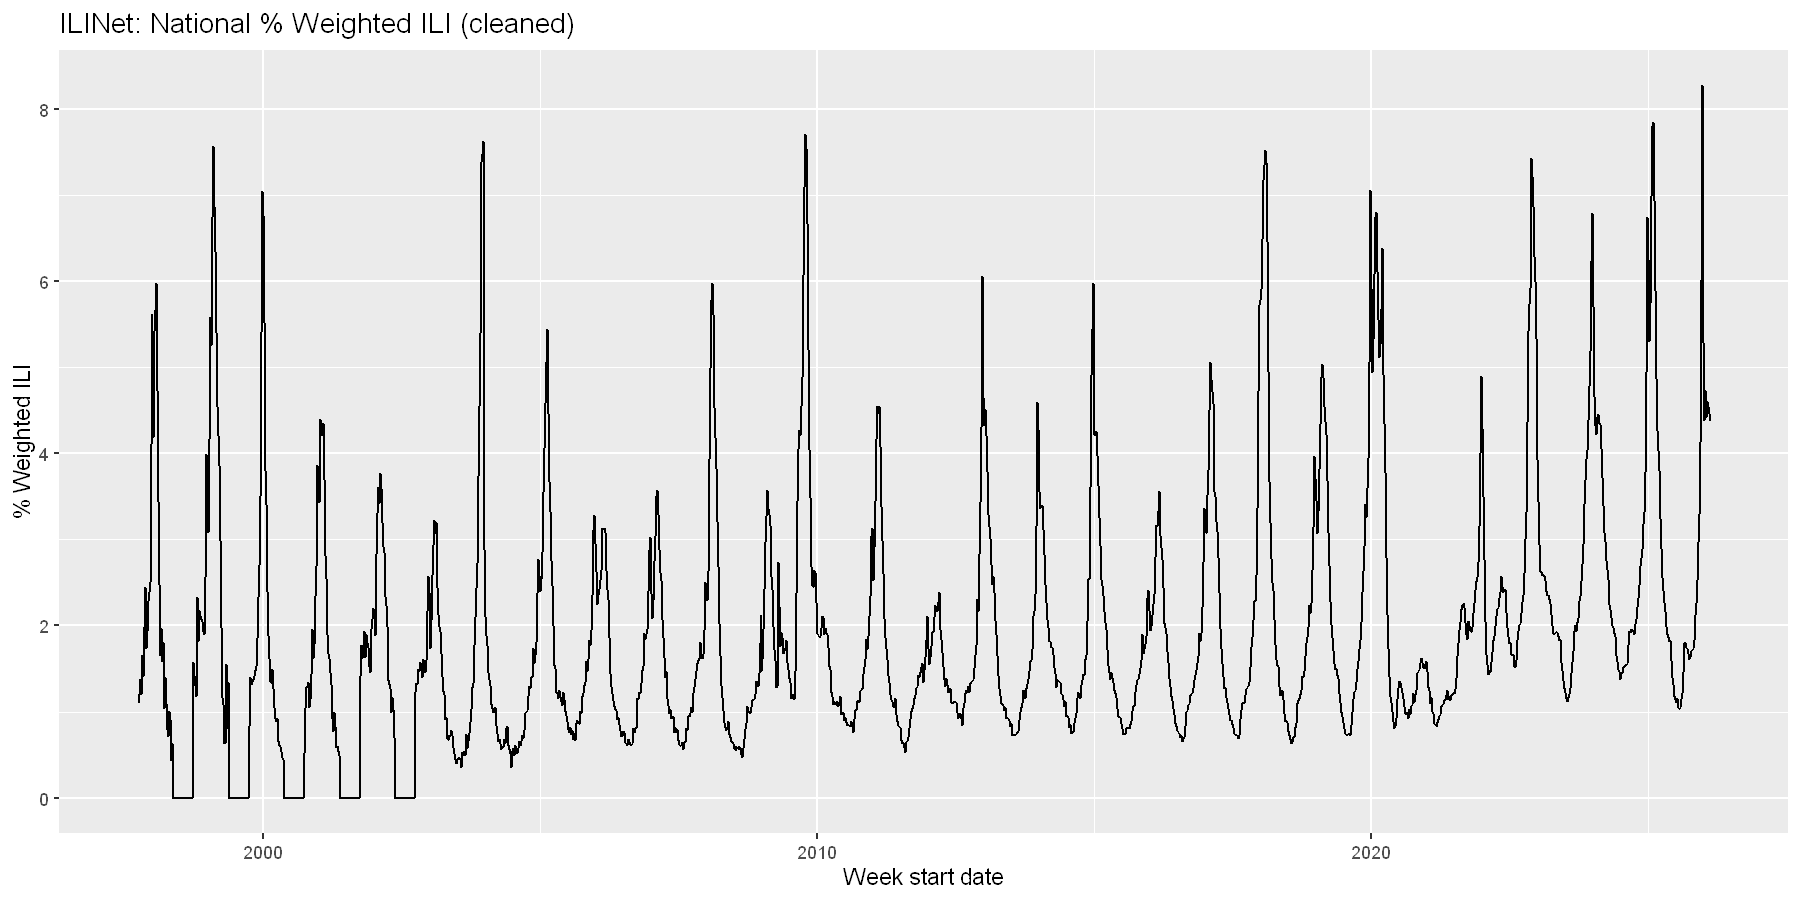

No HHS Region rows found in `ilinet` (or `region` is missing); skipping faceted plot p3.



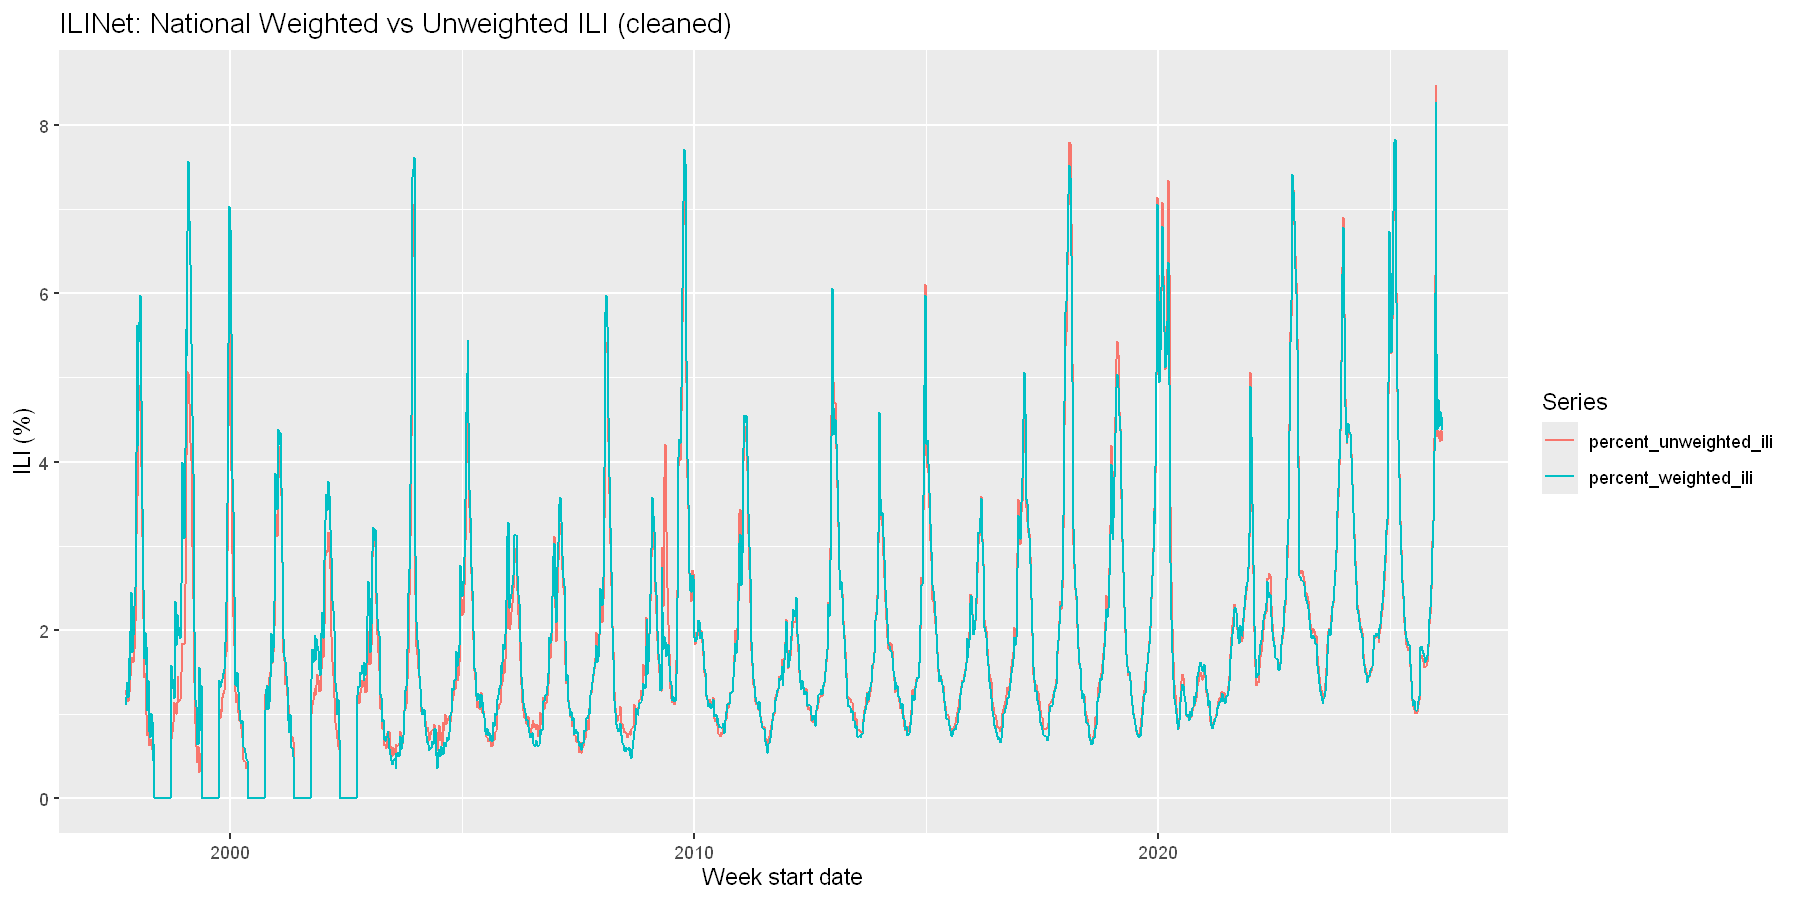

Warning message:
"Removed 4 rows containing missing values or values outside the scale range
(`geom_line()`)."


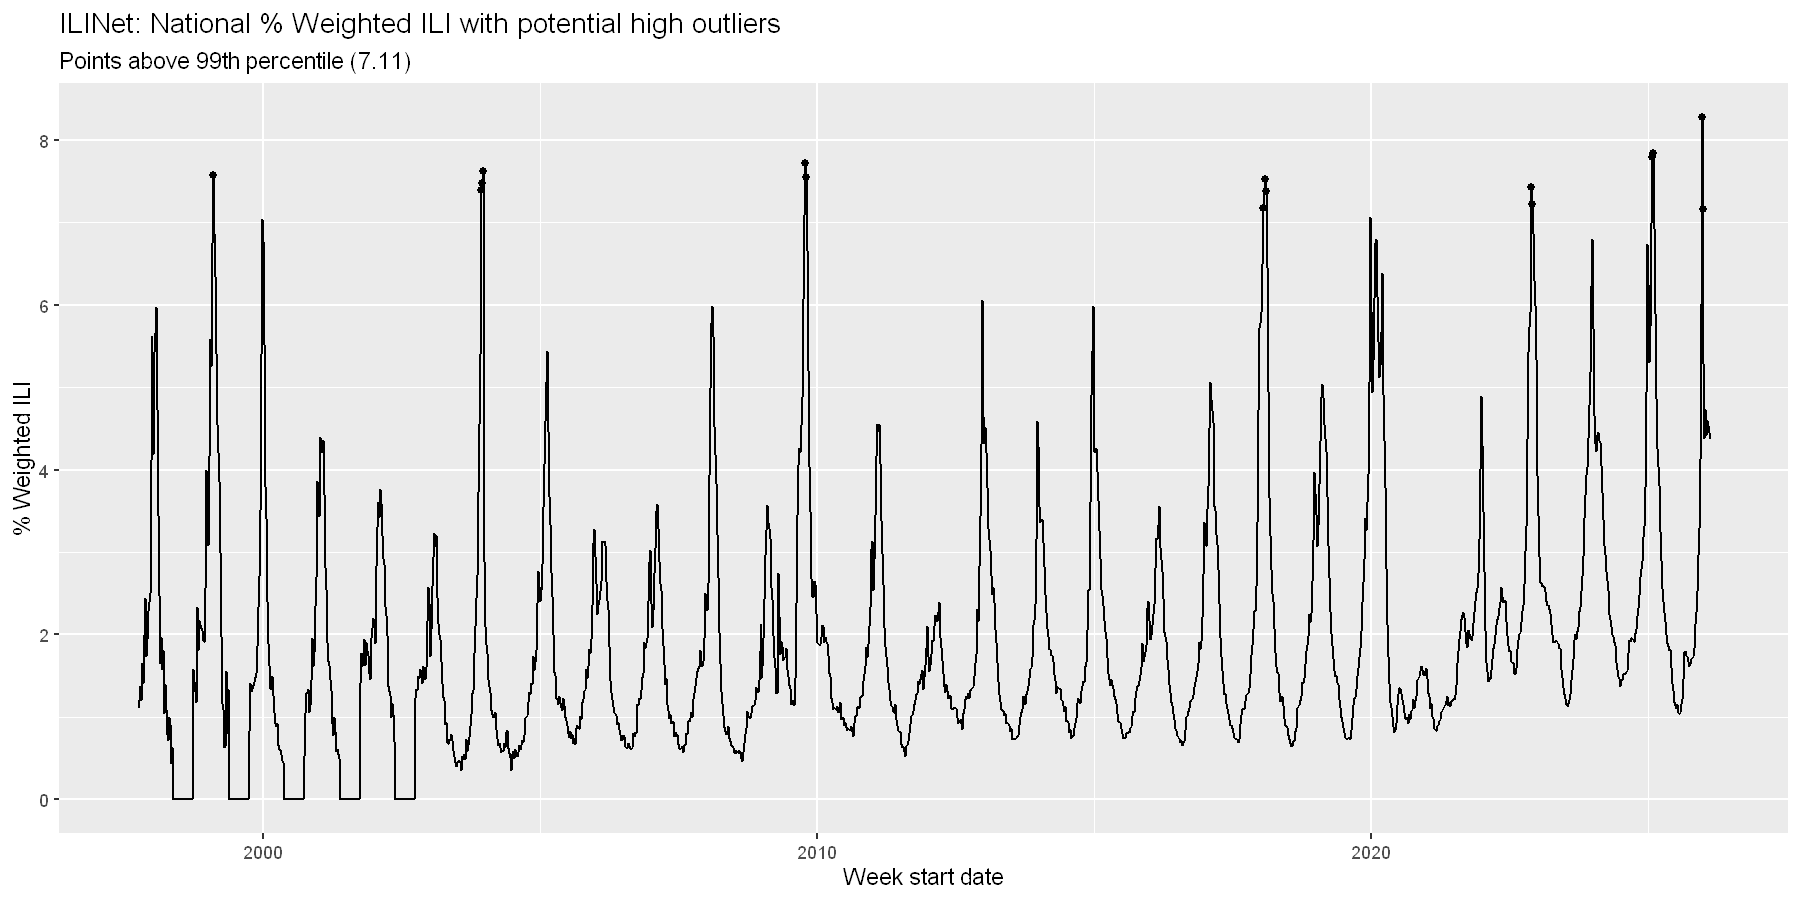

Found duplicated `week_start` rows in National data; aggregating before tsibble.



# A tibble: 5 × 2
  week_start     n
  <date>     <int>
1 1997-12-29     2
2 2003-12-29     2
3 2008-12-29     2
4 2014-12-29     2
5 2025-12-29     2


[1] TRUE

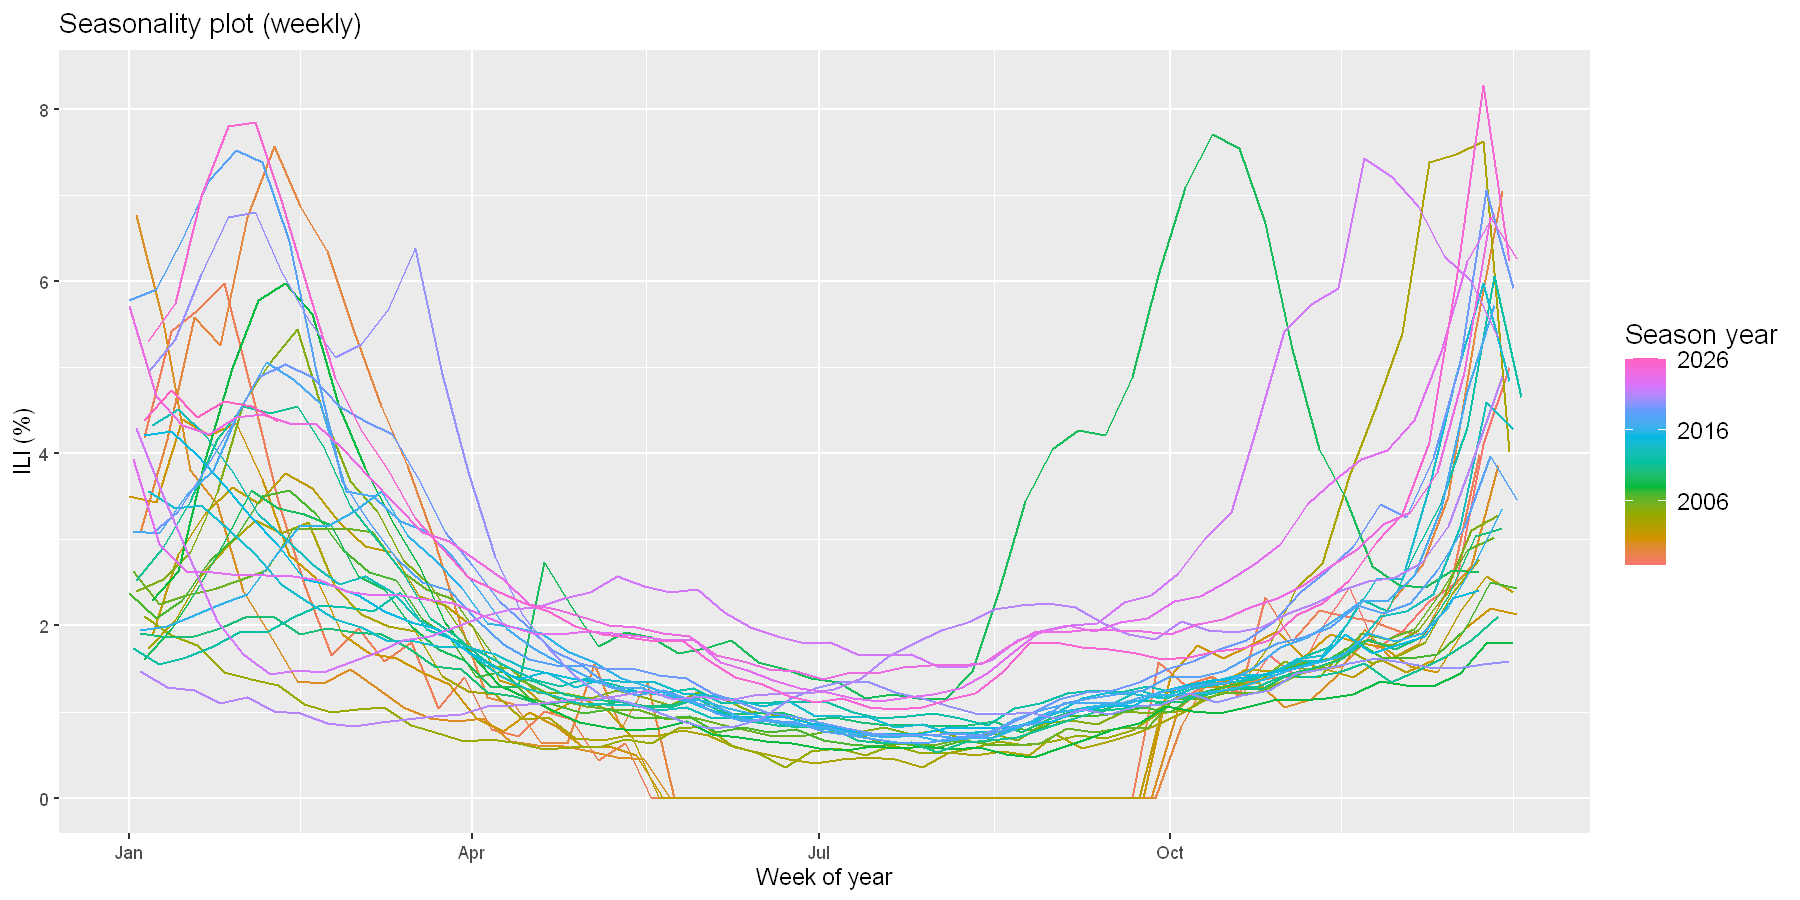

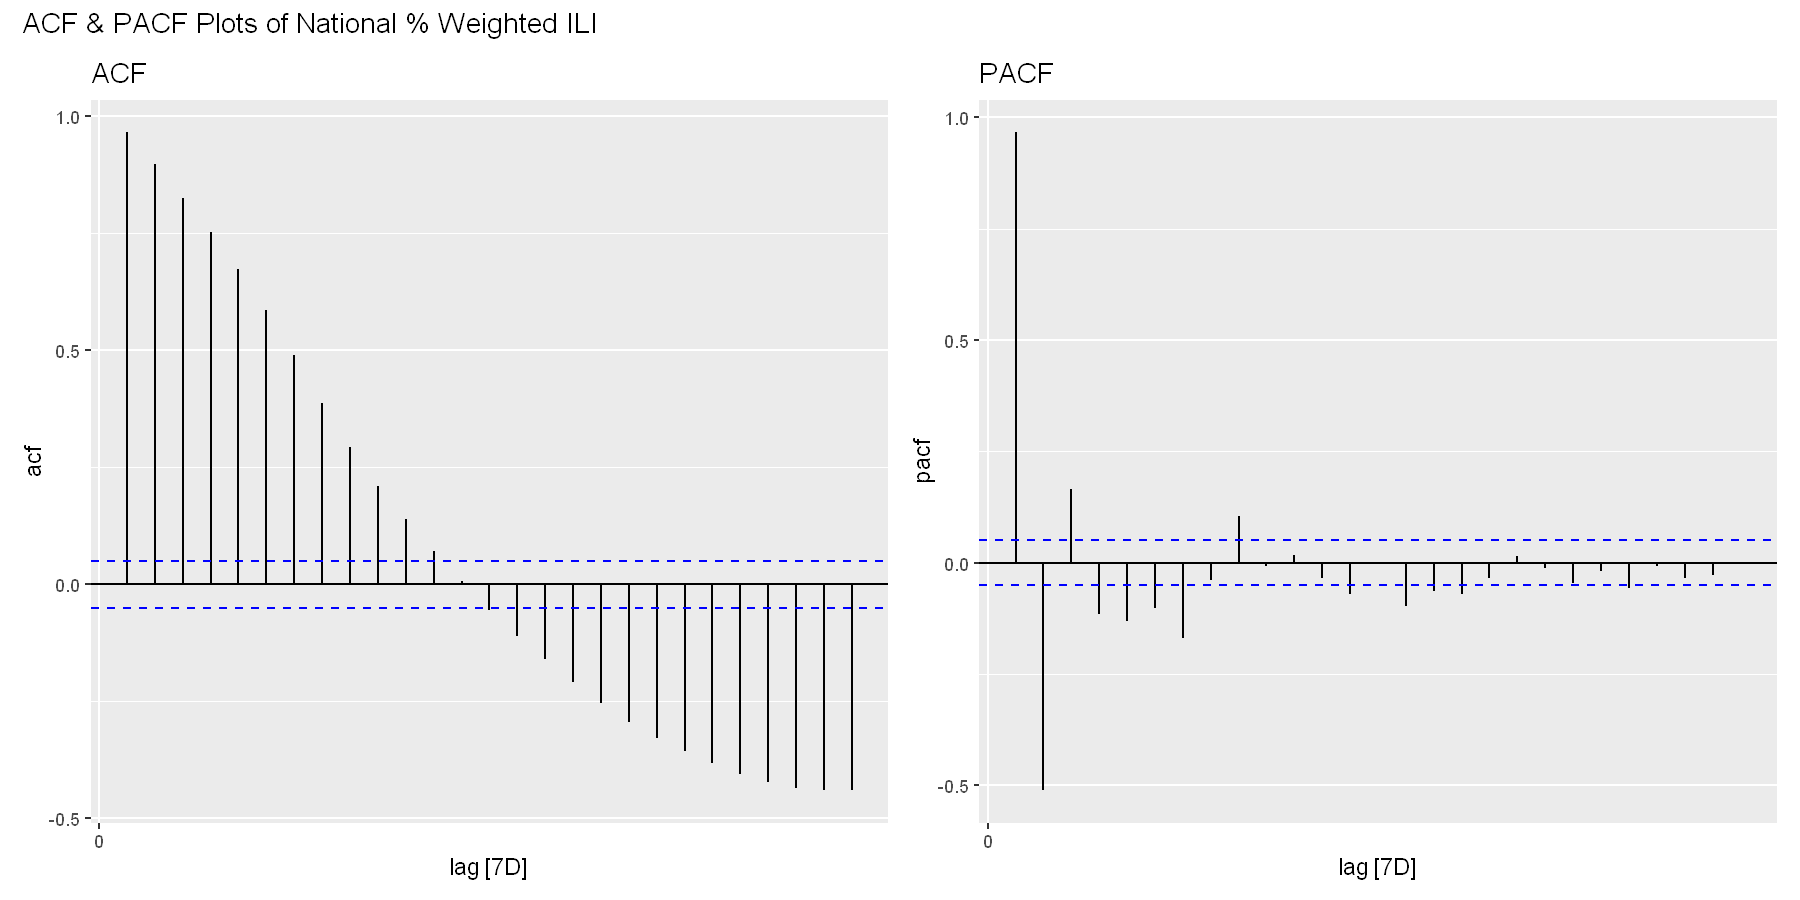

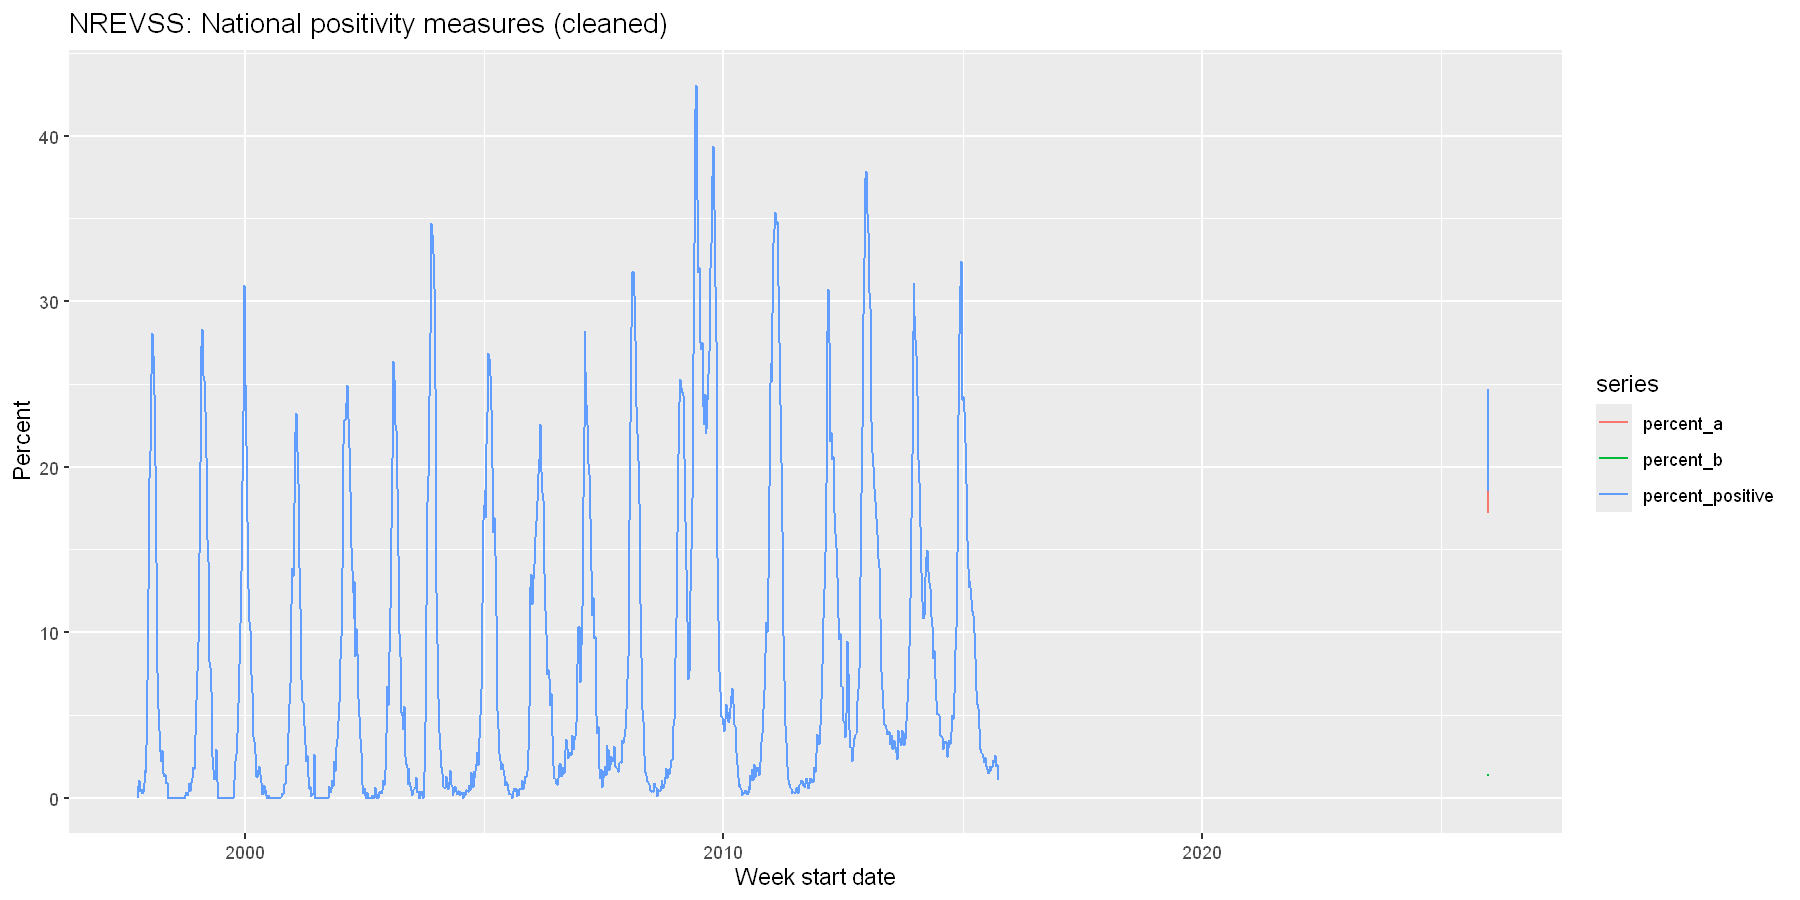

In [9]:
# ============================================================
# Plot + data checks for cleaned FluView data
# Assumes you've already created: ilinet, nrevss
# (from the previous cleaning script)
# ============================================================

# ----------------------------
# 1) Basic checks: structure + summaries
# ----------------------------
ilinet <- readr::read_rds("fluview_clean/ilinet_clean.rds")
nrevss <- readr::read_rds("fluview_clean/nrevss_clean.rds")

glimpse(ilinet)
glimpse(nrevss)

# fast summaries
summary(ilinet$percent_weighted_ili)
summary(ilinet$percent_unweighted_ili)

# more comprehensive summary
skimr::skim(ilinet)
skimr::skim(nrevss)

# missingness overview
naniar::miss_var_summary(ilinet)
naniar::miss_var_summary(nrevss)

# ----------------------------
# 2) Integrity checks: duplicates + time gaps
# ----------------------------

# duplicates in ILINet keys
ilinet_dups <- dplyr::count(ilinet, region_type, region, year, week)
ilinet_dups <- dplyr::filter(ilinet_dups, n > 1)

print(ilinet_dups)

# ensure weekly continuity for each (region_type, region)
# (this flags missing weeks in the time index)
ilinet_gaps <- ilinet
ilinet_gaps <- dplyr::group_by(ilinet_gaps, region_type, region)
ilinet_gaps <- dplyr::arrange(ilinet_gaps, week_start, .by_group = TRUE)
ilinet_gaps <- dplyr::mutate(
  ilinet_gaps,
  gap_days = as.numeric(week_start - dplyr::lag(week_start))
 )
ilinet_gaps <- dplyr::filter(ilinet_gaps, !is.na(gap_days) & gap_days != 7)
ilinet_gaps <- dplyr::ungroup(ilinet_gaps)

print(ilinet_gaps)

# same idea for NREVSS (if you use it)
nrevss_dups <- dplyr::count(nrevss, source_file, region_type, region, year, week)
nrevss_dups <- dplyr::filter(nrevss_dups, n > 1)

print(nrevss_dups)

# ----------------------------
# 3) Plot the cleaned ILINet series
# ----------------------------

# A) National time series (weighted ILI)
ilinet_national <- dplyr::filter(ilinet, region_type == "National")

p1 <- ggplot(ilinet_national, aes(x = week_start, y = percent_weighted_ili)) +
  geom_line(na.rm = TRUE) +
  labs(
    title = "ILINet: National % Weighted ILI (cleaned)",
    x = "Week start date",
    y = "% Weighted ILI"
  )
print(p1)

# B) Compare weighted vs unweighted (National)
p2_data <- dplyr::select(
  ilinet_national,
  week_start,
  percent_weighted_ili,
  percent_unweighted_ili
 )
p2_data <- tidyr::pivot_longer(
  p2_data,
  cols = -week_start,
  names_to = "series",
  values_to = "value"
 )

p2 <- ggplot(p2_data, aes(week_start, value, color = series)) +
  geom_line(na.rm = TRUE) +
  labs(
    title = "ILINet: National Weighted vs Unweighted ILI (cleaned)",
    x = "Week start date",
    y = "ILI (%)",
    color = "Series"
  )
print(p2)

# C) Facet by region (example: HHS Regions)
# Some cleaned datasets may not include HHS rows; guard against empty data.
ilinet_hhs <- ilinet
ilinet_hhs <- dplyr::filter(
  ilinet_hhs,
  stringr::str_detect(region_type, regex("HHS", ignore_case = TRUE))
 )
ilinet_hhs <- dplyr::filter(ilinet_hhs, !is.na(region) & region != "")

if (nrow(ilinet_hhs) > 0) {
  p3 <- ggplot(ilinet_hhs, aes(x = week_start, y = percent_weighted_ili)) +
    geom_line(na.rm = TRUE) +
    facet_wrap(~ region, scales = "free_y") +
    labs(
      title = "ILINet: % Weighted ILI by HHS Region (cleaned)",
      x = "Week start date",
      y = "% Weighted ILI"
    )
  print(p3)
} else {
  message("No HHS Region rows found in `ilinet` (or `region` is missing); skipping faceted plot p3.")
}

# D) Quick outlier check: points above 99th percentile (National)
thr <- quantile(ilinet_national$percent_weighted_ili, 0.99, na.rm = TRUE)

p4_outliers <- dplyr::filter(ilinet_national, percent_weighted_ili > thr)

p4 <- ggplot(ilinet_national, aes(week_start, percent_weighted_ili)) +
  geom_line(na.rm = TRUE) +
  geom_point(
    data = p4_outliers,
    na.rm = TRUE
  ) +
  labs(
    title = "ILINet: National % Weighted ILI with potential high outliers",
    subtitle = paste0("Points above 99th percentile (", round(thr, 2), ")"),
    x = "Week start date",
    y = "% Weighted ILI"
  )
print(p4)

# ----------------------------
# 4) Seasonal checks (very useful for forecasting)
# ----------------------------

# Create "season week" index (week within flu season) if you want:
# Many define season as starting around week 40; adjust if you like.
ilinet_national2 <- dplyr::mutate(
  ilinet_national,
  season_year = dplyr::if_else(week >= 40, year, year - 1),
  season_week = dplyr::if_else(week >= 40, week - 39, week + 13)
  # makes week 40 -> 1, ... week 52 -> 13, week 1 -> 14, ...
 )

p5 <- ggplot(ilinet_national2, aes(season_week, percent_weighted_ili, group = season_year)) +
  geom_line(alpha = 0.6, na.rm = TRUE) +
  labs(
    title = "ILINet: Seasonal plot (National % Weighted ILI)",
    x = "Week within flu season (approx; start at week 40)",
    y = "% Weighted ILI"
  )

y_tbl <- ilinet_national |>
  dplyr::select(week_start, percent_weighted_ili) |>
  dplyr::group_by(week_start) |>
  dplyr::summarise(
    percent_weighted_ili = mean(percent_weighted_ili, na.rm = TRUE),
    .groups = "drop"
  ) |>
  dplyr::arrange(week_start) |>
  tsibble::as_tsibble(index = week_start) |>
  tsibble::fill_gaps(.full = TRUE)

p5 <- feasts::gg_season(y_tbl, percent_weighted_ili, period = "year") +
  labs(
    title = "Seasonality plot (weekly)",
    x = "Week of year",
    y = "ILI (%)",
    color = "Season year"
  ) +
  theme(
    legend.position = "right",
    legend.title = element_text(size = 13),
    legend.text = element_text(size = 11),
    legend.key.size = grid::unit(0.7, "cm")
  )

print(p5)

# ----------------------------
# 5) Autocorrelation checks (ACF) using tsibble + feasts
# ----------------------------

# Turn into a tsibble (regular weekly index)
# Note: `as_tsibble()` requires each index value (week_start) to be unique.
# If the cleaned data contains duplicates for the same week, we aggregate them.
ilinet_week_dups <- dplyr::count(ilinet_national, week_start)
ilinet_week_dups <- dplyr::filter(ilinet_week_dups, n > 1)

if (nrow(ilinet_week_dups) > 0) {
  message("Found duplicated `week_start` rows in National data; aggregating before tsibble.")
  print(ilinet_week_dups)
}

ilinet_ts <- dplyr::select(ilinet_national, week_start, percent_weighted_ili)
ilinet_ts <- dplyr::group_by(ilinet_ts, week_start)
ilinet_ts <- dplyr::summarise(
  ilinet_ts,
  percent_weighted_ili = mean(percent_weighted_ili, na.rm = TRUE),
  .groups = "drop"
 )
ilinet_ts <- dplyr::mutate(
  ilinet_ts,
  percent_weighted_ili = ifelse(is.nan(percent_weighted_ili), NA_real_, percent_weighted_ili)
 )
ilinet_ts <- dplyr::arrange(ilinet_ts, week_start)
ilinet_ts <- tsibble::as_tsibble(ilinet_ts, index = week_start)

# Make implicit time gaps explicit (required by feasts::ACF/PACF)
ilinet_ts <- tsibble::fill_gaps(ilinet_ts, .full = TRUE)

# Check if regular weekly
is_regular(ilinet_ts)

# ACF / PACF plots (helps pick ARIMA structure)
# acf_tbl <- feasts::ACF(ilinet_ts, percent_weighted_ili)
# p_acf <- autoplot(acf_tbl) +
#   labs(title = "ACF: National % Weighted ILI")
# print(p_acf)

# pacf_tbl <- feasts::PACF(ilinet_ts, percent_weighted_ili)
# p_pacf <- autoplot(pacf_tbl) +
#   labs(title = "PACF: National % Weighted ILI")
# print(p_pacf)

# ACF / PACF plots (helps pick ARIMA structure)
acf_tbl <- feasts::ACF(ilinet_ts, percent_weighted_ili)
p_acf <- autoplot(acf_tbl) +
  labs(title = "ACF")

pacf_tbl <- feasts::PACF(ilinet_ts, percent_weighted_ili)
p_pacf <- autoplot(pacf_tbl) +
  labs(title = "PACF")

# Put plots side-by-side with shared title
library(patchwork)

figure_2 <- p_acf + p_pacf +
  plot_annotation(
    title = "ACF & PACF Plots of National % Weighted ILI"
  )

print(figure_2)

# ----------------------------
# 6) (Optional) Plot NREVSS positivity (if available)
# ----------------------------
if (nrow(nrevss) > 0) {
  nrevss_nat <- dplyr::filter(nrevss, region_type == "National")

  # Try to find a sensible positivity column if present
  possible <- intersect(names(nrevss_nat), c("percent_positive", "percent_a", "percent_b"))
  if (length(possible) > 0) {
    p6_data <- dplyr::select(nrevss_nat, week_start, dplyr::any_of(possible))
    p6_data <- tidyr::pivot_longer(
      p6_data,
      cols = -week_start,
      names_to = "series",
      values_to = "value"
    )

    p6 <- ggplot(p6_data, aes(week_start, value, color = series)) +
      geom_line(na.rm = TRUE) +
      labs(
        title = "NREVSS: National positivity measures (cleaned)",
        x = "Week start date",
        y = "Percent"
      )
    print(p6)
  }
}

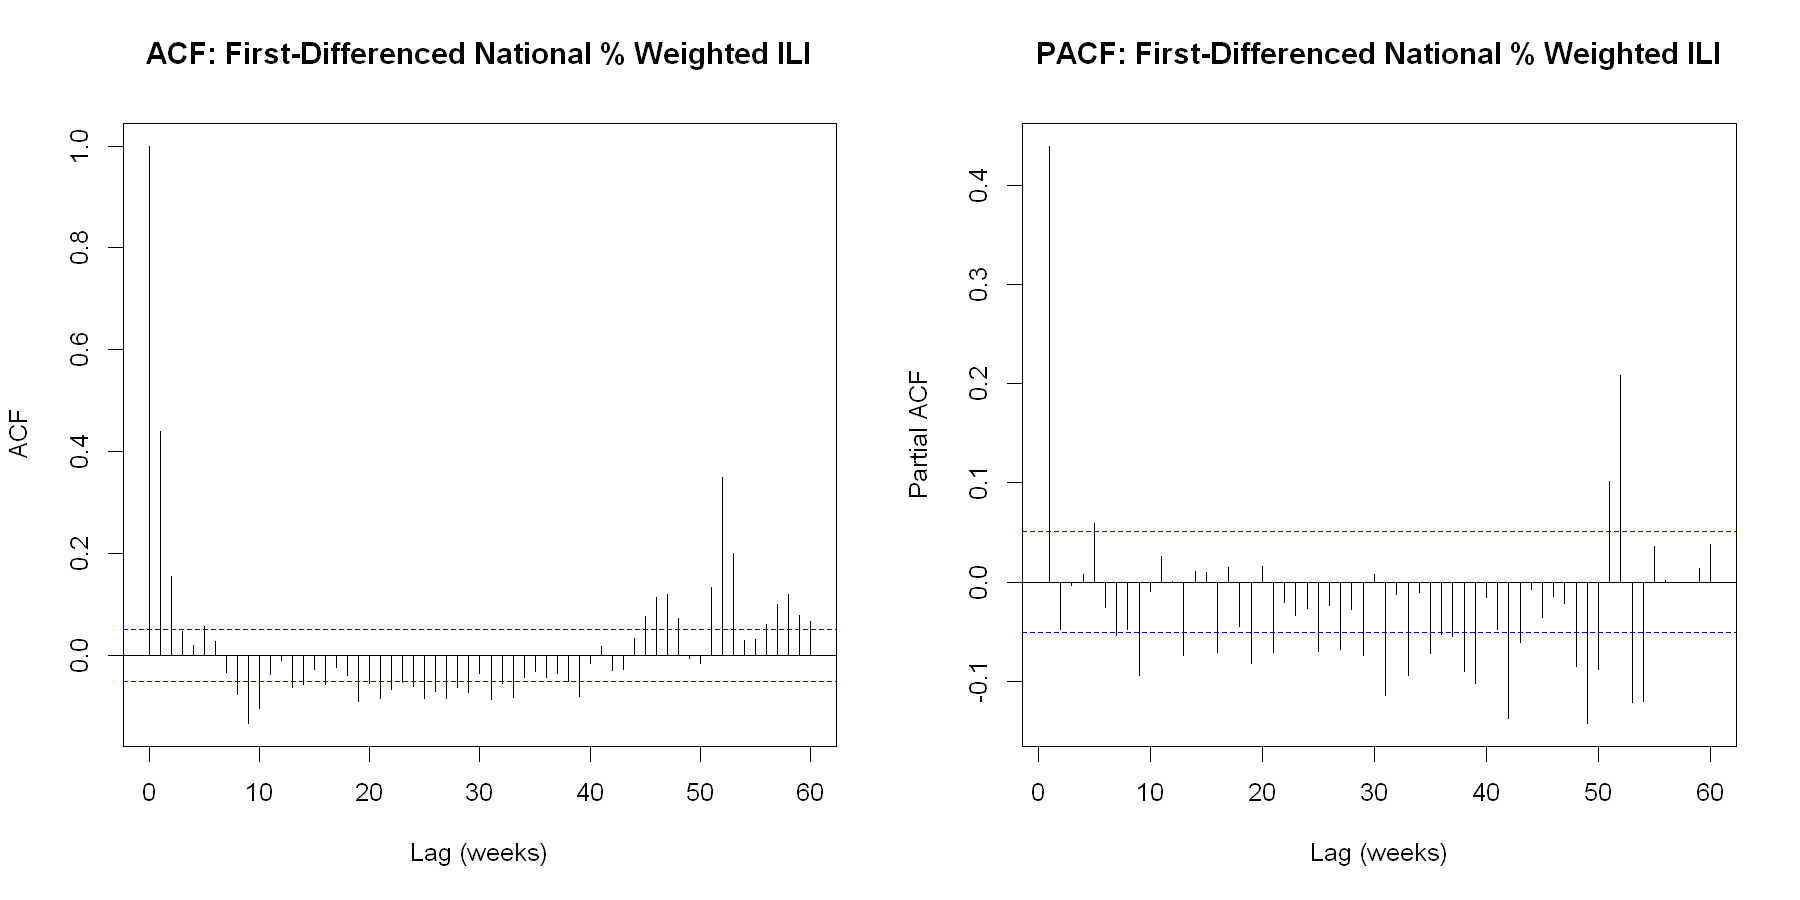

In [8]:
# ACF and PACF of first-differenced series
ilinet_national_diff <- ilinet_national %>%
  arrange(week_start) %>%
  mutate(diff_ili = c(NA, diff(percent_weighted_ili))) %>%
  filter(!is.na(diff_ili))

par(mfrow = c(1, 2))

acf(
  ilinet_national_diff$diff_ili,
  lag.max = 60,
  main    = "ACF: First-Differenced National % Weighted ILI",
  xlab    = "Lag (weeks)"
)

pacf(
  ilinet_national_diff$diff_ili,
  lag.max = 60,
  main    = "PACF: First-Differenced National % Weighted ILI",
  xlab    = "Lag (weeks)"
)

par(mfrow = c(1, 1))

**Interpretation of Differenced ACF & PACF Plots**:

We see stationarity, since the ACF drops to near zero after lags 1-2 and stays within or near the confidence bands for most lags. The PACF cuts off sharply after lag 1-2 and stays within or near confidence bands most of the time.

However, there's a spike at lag 52, so there's likely seasonal non-stationarity at the 52-week cycle, so there are seasonal differences present as well.

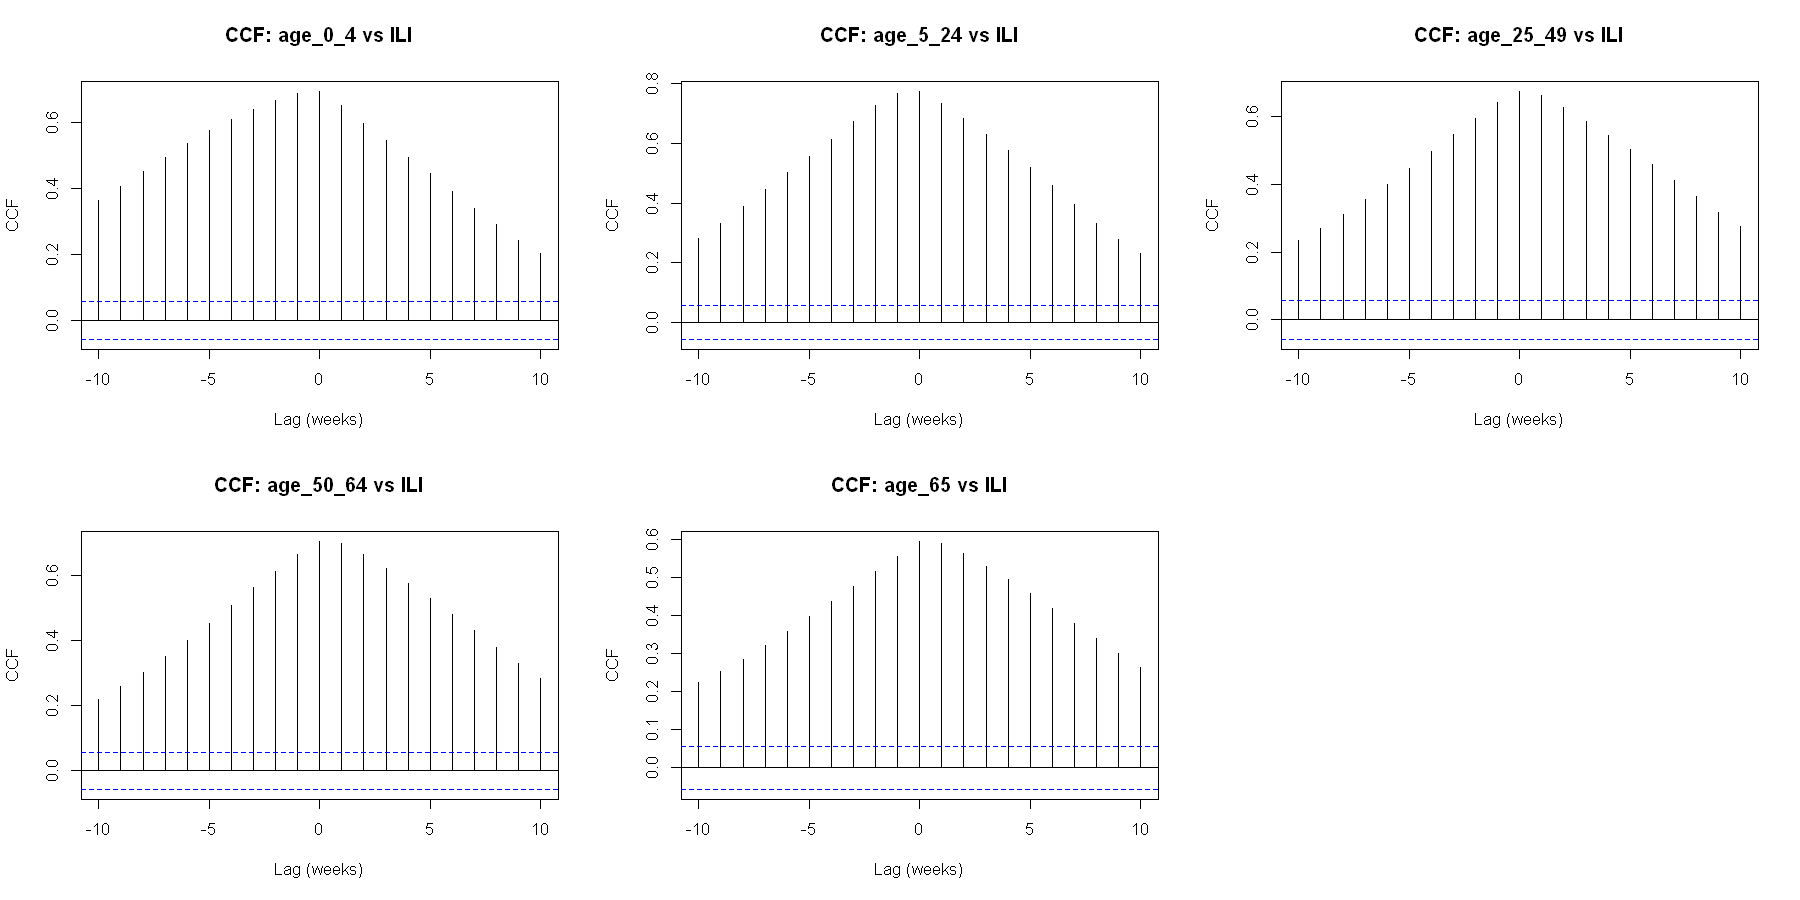

In [10]:
# CCF: lagged age covariates vs percent_weighted_ili
# (justifies lag-1 choice in ARIMAX)

df_ccf <- readr::read_rds("fluview_clean/df_tsibble.rds") |>
  as_tibble() |>
  filter(!is.na(percent_weighted_ili), !is.na(age_5_24))

par(mfrow = c(2, 3))

for (age_col in c("age_0_4", "age_5_24", "age_25_49", "age_50_64", "age_65")) {
  ccf(
    df_ccf[[age_col]],
    df_ccf$percent_weighted_ili,
    lag.max = 10,
    main = paste("CCF:", age_col, "vs ILI"),
    xlab = "Lag (weeks)",
    ylab = "CCF"
  )
}

par(mfrow = c(1, 1))

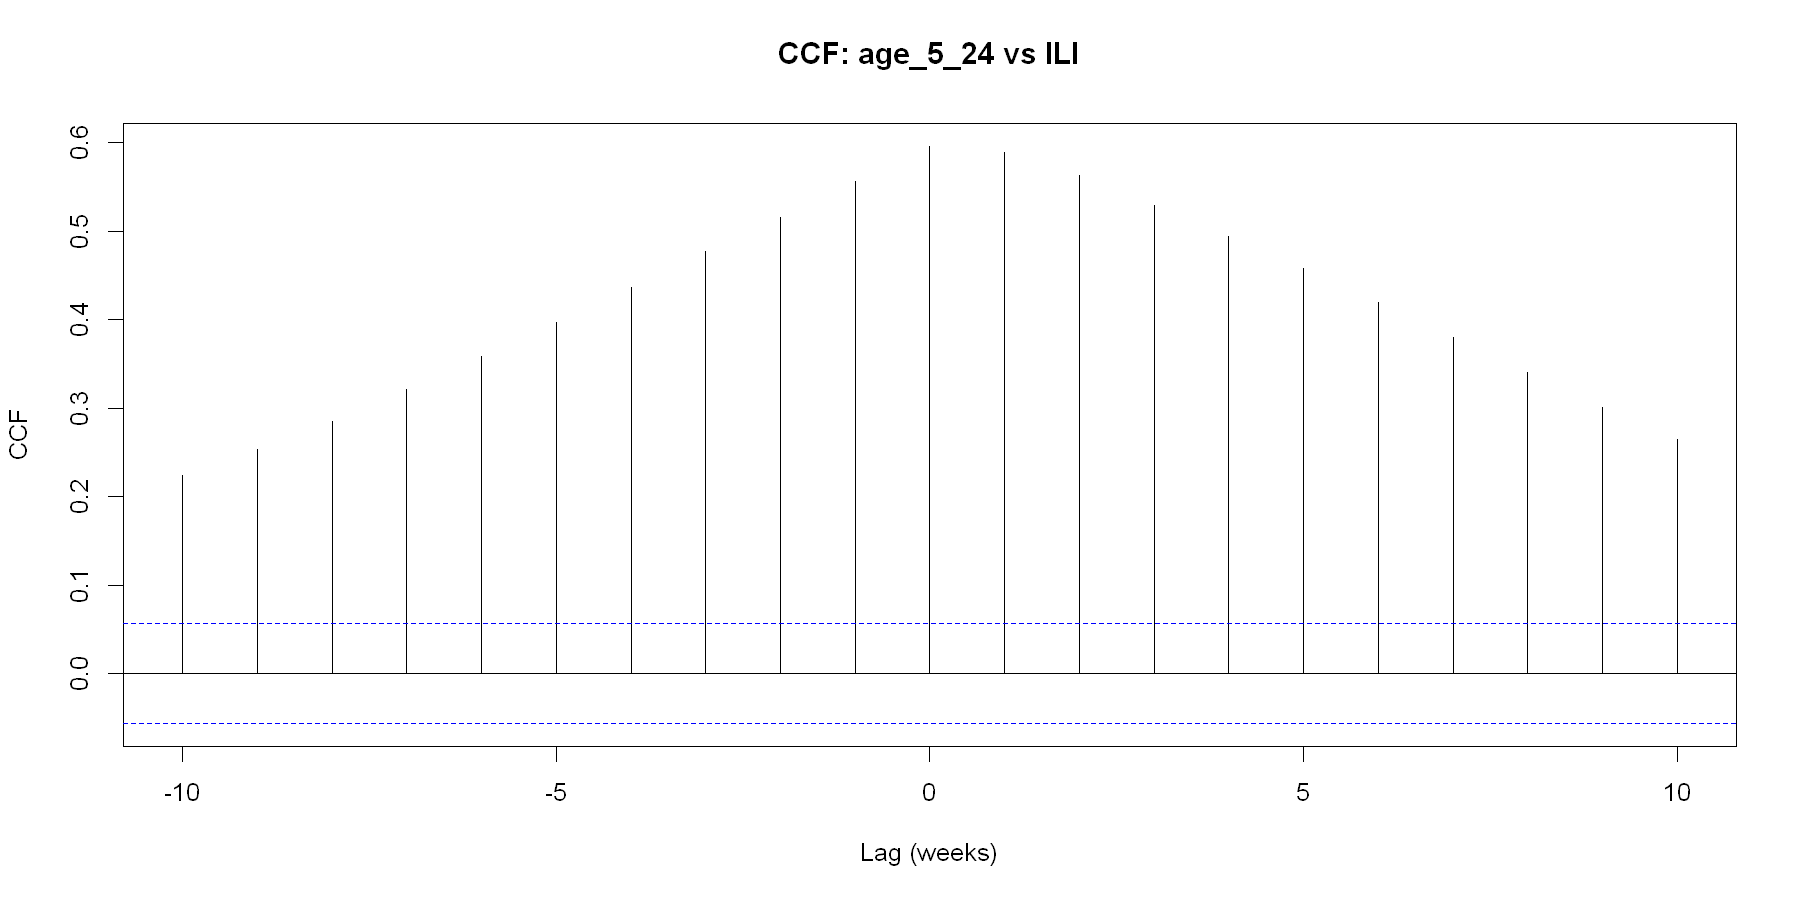

In [12]:
  ccf(
    df_ccf[[age_col]],
    df_ccf$percent_weighted_ili,
    lag.max = 10,
    main = paste("CCF:", "age_5_24", "vs ILI"),
    xlab = "Lag (weeks)",
    ylab = "CCF"
  )

In [13]:
df_plot <- readr::read_rds("fluview_clean/df_tsibble.rds") |>
  as_tibble() |>
  mutate(week_start = as.Date(as.character(week_start)))

holdout_start <- as.Date("2023-01-02")  # 2023 W01 Monday

ggplot(df_plot, aes(x = week_start, y = percent_weighted_ili)) +
  geom_line(color = "#2c7bb6", linewidth = 0.5) +
  geom_vline(xintercept = holdout_start, linetype = "dashed",
             color = "red", linewidth = 0.8) +
  annotate("text", x = holdout_start, y = max(df_plot$percent_weighted_ili, na.rm=TRUE) * 0.95,
           label = "Holdout start", hjust = -0.05, color = "red", size = 3.5) +
  labs(
    title = "National Percent Weighted ILI, 2002–2024",
    x = "Week start date",
    y = "Percent weighted ILI (%)"
  ) +
  theme_bw()

ERROR: [1m[33mError[39m in `mutate()`:[22m
[1m[22m[36mℹ[39m In argument: `week_start = as.Date(as.character(week_start))`.
[1mCaused by error in `charToDate()`:[22m
[33m![39m character string is not in a standard unambiguous format
